# Template Matching

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/oscar-ramos/robotica-autonoma-python/blob/main/3-Vision/3-2-Procesamiento-Imagen/3-2-4-Template-Matching.ipynb)

In [20]:
import numpy as np
from matplotlib import pyplot as plt

import cv2

Si se usa colab se puede utilizar las imágenes del repositorio, de lo contrario se pueden cargar manualmente.

In [ ]:
colab = True
if (colab):
    !wget -q https://github.com/oscar-ramos/robotica-autonoma-python/raw/main/3-Vision/3-2-Procesamiento-Imagen/imagenes/gatos.jpg
    !wget -q https://github.com/oscar-ramos/robotica-autonoma-python/raw/main/3-Vision/3-2-Procesamiento-Imagen/imagenes/gato3.jpg

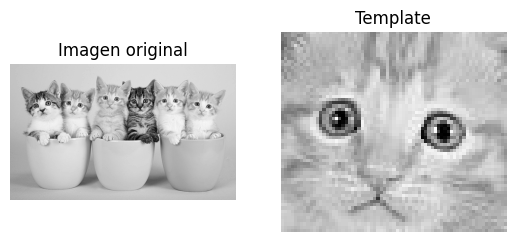

In [21]:
I = cv2.imread('gatos.jpg',0)
Itemplate = cv2.imread('gato3.jpg',0)
w, h = Itemplate.shape[::-1]

plt.subplot(121);
plt.imshow(I,cmap='gray'); plt.title('Imagen original'); plt.axis('off')
plt.subplot(122);
plt.imshow(Itemplate,cmap='gray'); plt.title('Template'); plt.axis('off')
plt.show()

Los posibles métodos para "template matching" son: `methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR', 'cv2.TM_CCORR_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']`


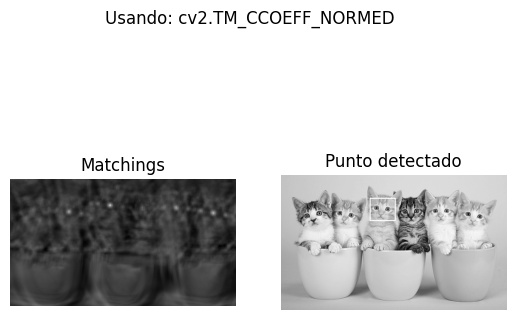

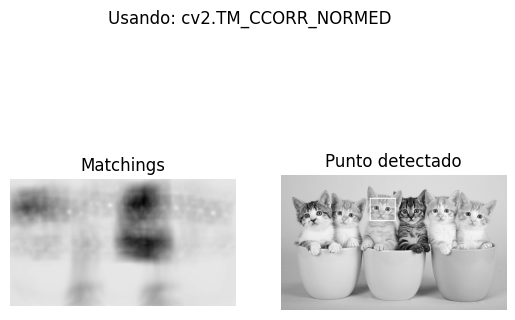

In [22]:
# Algunos métodos:
methods = ['cv2.TM_CCOEFF_NORMED','cv2.TM_CCORR_NORMED']

for method_str in methods:
    # Imagen de salida
    Iout = I.copy()
    # Métodos para template matching
    method = eval(method_str)
    # Aplicar template matching: Ires es la imagen con valore resultantes
    Ires = cv2.matchTemplate(I, Itemplate, method)
    # Extracción de máximos (y mínimos) valores de Ires
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(Ires)
    # Bordes del punto con mejor coincidencia (match)
    top_left = max_loc
    bottom_right = (top_left[0]+w, top_left[1]+h)
    # Rectángulo en el punto con mayor coincidencia
    cv2.rectangle(Iout, top_left, bottom_right, 255, 2)

    plt.subplot(121),
    plt.imshow(Ires, cmap='gray'); plt.title('Matchings'), plt.axis('off')
    plt.subplot(122)
    plt.imshow(Iout, cmap='gray'); plt.title('Punto detectado'), plt.axis('off')
    plt.suptitle("Usando: " + method_str)
    plt.show()

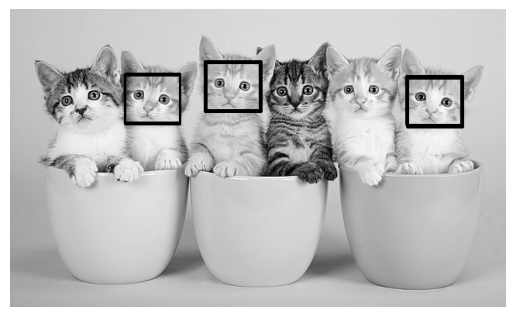

In [ ]:
# Mostrar más resultados (no solo el que hace más "match")
res = cv2.matchTemplate(I, Itemplate, cv2.TM_CCOEFF_NORMED)
threshold = 0.55
loc = np.where(res>=threshold)
for pt in zip(*loc[::-1]):
    cv2.rectangle(I, pt, (pt[0]+w, pt[1]+h), (0,0,255), 2)

plt.imshow(I, cmap='gray')
plt.axis('off'); plt.show()